In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/TheNextDecade/Diabetes"

Mounted at /content/drive
BPXO_L.xpt
diabetes_012_health_indicators_BRFSS2015.csv
diabetes_binary_5050split_health_indicators_BRFSS2015.csv
diabetes_binary_health_indicators_BRFSS2015.csv
SmartSensor_DiabetesMonitoring.csv
TCHOL_L.xpt


In [2]:
!pip install pyreadstat requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.7 MB/s eta 0:00:00


In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.7 MB/s eta 0:00:00


In [4]:
!pip install shap

In [5]:
!pip install -q -U transformers accelerate bitsandbytes huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 25.5 MB/s eta 0:00:00


In [51]:
import pandas as pd
import numpy as np
import pyreadstat
import requests
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report, confusion_matrix
import random
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import re
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login
import json


# **Data**

In [21]:
NHANSES_URLS = [
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
    # 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BMX_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/SLQ_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TCHOL_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/PAQ_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BPXO_L.xpt',
    'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/GHB_L.xpt'
    ]

In [22]:
def download_nhanes_with_labels(url):
    response = requests.get(url)
    df, meta = pyreadstat.read_xport(BytesIO(response.content), encoding='latin1')
    return df, meta

def import_nhanes_xpt(urls):
    if isinstance(urls, str): urls = [urls]

    final_df = pd.DataFrame()
    all_labels = {}

    for i, url in enumerate(urls):
        df, meta = download_nhanes_with_labels(url)

        all_labels.update(meta.column_names_to_labels)

        if i == 0:
            final_df = df
        else:
            final_df = pd.merge(final_df, df, on='SEQN', how='inner')

    all_labels['SEQN'] = 'Patient_ID'
    final_df = final_df.rename(columns=all_labels)

    return final_df

In [23]:
raw_df = import_nhanes_xpt(NHANSES_URLS)
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6337 entries, 0 to 6336
Data columns (total 56 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Patient_ID                                6337 non-null   float64
 1   Data release cycle                        6337 non-null   float64
 2   Interview/Examination status              6337 non-null   float64
 3   Gender                                    6337 non-null   float64
 4   Age in years at screening                 6337 non-null   float64
 5   Age in months at screening - 0 to 24 mos  0 non-null      float64
 6   Race/Hispanic origin                      6337 non-null   float64
 7   Race/Hispanic origin w/ NH Asian          6337 non-null   float64
 8   Six-month time period                     6337 non-null   float64
 9   Age in months at exam - 0 to 19 years     264 non-null    float64
 10  Served active duty in US Armed Force

# **Data Reduction & Data Smapling**

In [24]:
selected_features = {
    # ข้อมูลพื้นฐาน
    'Patient_ID': 'ID',
    'Gender': 'Gender',
    'Age in years at screening': 'Age',

    # 'BMI Category - Children/Youth': 'BMI',

    # การนอน
    'Sleep hours - weekdays or workdays': 'Sleep_Hours',

    # กิจกรรม (นาทีต่อวัน)
    'Minutes sedentary activity': 'Sedentary_Minutes',
    'Minutes moderate LTPA': 'Moderate_Activity_Minutes',
    'Minutes vigorous LTPA': 'Vigorous_Activity_Minutes',

    # สุขภาพอื่นๆ (เอาไว้เสริมความแม่นยำ)
    'Total Cholesterol (mg/dL)': 'Cholesterol',

    # หัวใจและความดัน (เก็บมาทุกรอบก่อนเพื่อทำ Feature Engineering)
    'Pulse - 1st oscillometric reading': 'Pulse_1',
    'Pulse - 2nd oscillometric reading': 'Pulse_2',
    'Pulse - 3rd oscillometric reading': 'Pulse_3',
    'Systolic - 1st oscillometric reading': 'Sys_1',
    'Systolic - 2nd oscillometric reading': 'Sys_2',
    'Systolic - 3rd oscillometric reading': 'Sys_3',
    'Diastolic - 1st oscillometric reading': 'Dia_1',
    'Diastolic - 2nd oscillometric reading': 'Dia_2',
    'Diastolic - 3rd oscillometric reading': 'Dia_3',

    # ตัวแปรเป้าหมาย (Label)
    'Glycohemoglobin (%)': 'HbA1c'
}

In [25]:
selected_df = raw_df[selected_features.keys()].rename(columns=selected_features)

In [26]:
selected_df = selected_df.dropna(subset=['HbA1c'])

selected_df['Resting_HR'] = selected_df[['Pulse_2', 'Pulse_3']].mean(axis=1)
selected_df['Systolic_BP'] = selected_df[['Sys_2', 'Sys_3']].mean(axis=1)
selected_df['Diastolic_BP'] = selected_df[['Dia_2', 'Dia_3']].mean(axis=1)

# selected_df['Is_Diabetes'] = (selected_df['HbA1c'] >= 6.5).astype(int)

cols_to_drop = ['ID', 'Pulse_1', 'Pulse_2', 'Pulse_3', 'Sys_1', 'Sys_2', 'Sys_3', 'Dia_1', 'Dia_2', 'Dia_3']
selected_first_clean_df = selected_df.drop(columns=cols_to_drop)

In [27]:
selected_first_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6002 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     6002 non-null   float64
 1   Age                        6002 non-null   float64
 2   Sleep_Hours                5939 non-null   float64
 3   Sedentary_Minutes          5996 non-null   float64
 4   Moderate_Activity_Minutes  4781 non-null   float64
 5   Vigorous_Activity_Minutes  2725 non-null   float64
 6   Cholesterol                5714 non-null   float64
 7   HbA1c                      6002 non-null   float64
 8   Resting_HR                 5807 non-null   float64
 9   Systolic_BP                5807 non-null   float64
 10  Diastolic_BP               5807 non-null   float64
dtypes: float64(11)
memory usage: 562.7 KB


In [28]:
selected_first_clean_df

,Gender,Age,Sleep_Hours,Sedentary_Minutes,Moderate_Activity_Minutes,Vigorous_Activity_Minutes,Cholesterol,HbA1c,Resting_HR,Systolic_BP,Diastolic_BP
0,1.0,43.0,9.5,360.0,45.0,45.0,264.0,5.6,80.5,131.5,95.0
1,1.0,66.0,9.0,480.0,45.0,45.0,214.0,5.6,72.0,115.0,76.0
2,2.0,44.0,8.0,240.0,20.0,NaN,187.0,6.2,80.0,108.0,78.0
3,1.0,34.0,7.5,180.0,30.0,30.0,183.0,5.1,64.0,117.5,74.5
4,2.0,68.0,3.0,1200.0,NaN,NaN,203.0,5.9,78.5,140.5,76.0
...,...,...,...,...,...,...,...,...,...,...,...
6331,2.0,69.0,8.0,360.0,60.0,NaN,110.0,8.1,75.0,126.0,68.5
6332,2.0,76.0,9.0,480.0,40.0,NaN,180.0,6.0,70.5,146.0,78.5
6333,2.0,49.0,7.0,480.0,15.0,NaN,205.0,6.2,68.5,131.5,72.5
6335,1.0,40.0,8.0,240.0,15.0,NaN,255.0,5.2,81.0,126.5,81.5


In [29]:
initial_count = len(selected_first_clean_df)

# กฎที่ 1: อายุ (Age) - NHANES ปกติจะดักที่ 80 ปีอยู่แล้ว แต่เรากันเหนียวไว้ที่ 100
condition_age = (selected_first_clean_df['Age'] >= 0) & (selected_first_clean_df['Age'] <= 100)

# กฎที่ 2: อัตราการเต้นหัวใจขณะพัก (Resting_HR)
# ตามสถิติ ต่ำกว่า 30 หรือสูงกว่า 200 ในขณะนั่งพักคือความผิดปกติของข้อมูลหรือภาวะฉุกเฉิน
condition_hr = (selected_first_clean_df['Resting_HR'] >= 30) & (selected_first_clean_df['Resting_HR'] <= 200)

# กฎที่ 3: ชั่วโมงการนอน (Sleep_Hours)
# การตอบว่านอน 0 ชั่วโมง หรือ 24 ชั่วโมง มักจะเป็นความผิดพลาดในการกรอกข้อมูล
condition_sleep = (selected_first_clean_df['Sleep_Hours'] >= 2) & (selected_first_clean_df['Sleep_Hours'] <= 16)

# กฎที่ 4: ความดันโลหิต (Blood Pressure)
# ค่าตัวบน (Systolic) ต้องมากกว่าตัวล่าง (Diastolic) และไม่อยู่ในระดับที่มนุษย์อยู่ไม่ได้
condition_bp = (selected_first_clean_df['Systolic_BP'] > selected_first_clean_df['Diastolic_BP']) & \
               (selected_first_clean_df['Systolic_BP'] <= 250) & \
               (selected_first_clean_df['Diastolic_BP'] >= 40)

# กฎที่ 5: กิจกรรม (Activity)
# นาทีที่นั่งนิ่งๆ หรือออกกำลังกาย ต้องไม่เกิน 1,440 นาที (24 ชม.)
condition_activity = (selected_first_clean_df['Sedentary_Minutes'] <= 1440) & \
                     (selected_first_clean_df['Moderate_Activity_Minutes'] <= 1440)

# 2. รวมกฎทั้งหมดเข้าด้วยกัน
# ใช้เครื่องหมาย & (AND) เพื่อบอกว่าต้องผ่านทุกกฎ
all_conditions = condition_age & condition_hr & condition_sleep & condition_bp & condition_activity

# 3. กรองข้อมูล (Filter)
# เราจะเลือกเฉพาะแถวที่ผ่านทุกเงื่อนไข หรือเป็นค่าว่าง (NaN)
# *หมายเหตุ: เราจะไม่ลบ NaN ที่นี่ เพราะเดี๋ยวเราจะใช้ Imputer จัดการใน Pipeline*
remove_outliner_df = selected_first_clean_df[all_conditions | selected_first_clean_df.isna().any(axis=1)]

# 4. ตรวจสอบผล
final_count = len(remove_outliner_df)
print(f"ลบข้อมูลที่ผิดปกติออกไป: {initial_count - final_count} แถว")
print(f"คงเหลือข้อมูลคุณภาพ: {final_count} แถว")

ลบข้อมูลที่ผิดปกติออกไป: 8 แถว
คงเหลือข้อมูลคุณภาพ: 5994 แถว


In [30]:
remove_outliner_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5994 entries, 0 to 6336
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Gender                     5994 non-null   float64
 1   Age                        5994 non-null   float64
 2   Sleep_Hours                5931 non-null   float64
 3   Sedentary_Minutes          5988 non-null   float64
 4   Moderate_Activity_Minutes  4773 non-null   float64
 5   Vigorous_Activity_Minutes  2717 non-null   float64
 6   Cholesterol                5706 non-null   float64
 7   HbA1c                      5994 non-null   float64
 8   Resting_HR                 5799 non-null   float64
 9   Systolic_BP                5799 non-null   float64
 10  Diastolic_BP               5799 non-null   float64
dtypes: float64(11)
memory usage: 561.9 KB


# **Feature Engineering**

In [69]:
clinical_notes = [
"ไม่มีโรคประจำตัว ออกกำลังกายสม่ำเสมอ วิ่งสัปดาห์ละ 4 ครั้ง",
"ตรวจสุขภาพประจำปีปกติ ไม่มีประวัติครอบครัวเป็นเบาหวาน",
"รับประทานอาหารค่อนข้างสมดุล และเดินออกกำลังกายทุกวัน",
"ไม่สูบบุหรี่ ไม่ดื่มแอลกอฮอล์ และนอนหลับเพียงพอ",
"น้ำหนักตัวคงที่มาหลายปี ไม่มีปัญหาสุขภาพสำคัญ",
"ชอบปั่นจักรยานเป็นประจำ ผลตรวจสุขภาพล่าสุดปกติ",
"ไม่มีประวัติความดันโลหิตสูงหรือโรคหัวใจ",
"ทำงานออฟฟิศแต่พยายามเดินครบวันละ 10000 ก้าว",
"ไม่พบความผิดปกติของระดับน้ำตาลในการตรวจครั้งก่อน",
"ออกกำลังกายแบบคาร์ดิโออย่างน้อย 150 นาทีต่อสัปดาห์",
"รับประทานผักและผลไม้เป็นประจำ ไม่มีประวัติโรคเรื้อรัง",
"ไม่มีสมาชิกในครอบครัวเป็นเบาหวาน",
"นอนหลับสม่ำเสมอและไม่ค่อยมีความเครียด",
"ค่าความดันโลหิตอยู่ในเกณฑ์ปกติตลอด",
"น้ำหนักอยู่ในเกณฑ์มาตรฐานของอายุ",
"ไม่สูบบุหรี่และไม่เคยได้รับการวินิจฉัยภาวะก่อนเบาหวาน",
"ชอบเล่นกีฬาเป็นประจำและมีสุขภาพโดยรวมดี",
"ไม่มีอาการผิดปกติเกี่ยวกับการเผาผลาญน้ำตาล",
"ตรวจสุขภาพทุกปี ผลเลือดปกติสม่ำเสมอ",
"ทำงานที่ต้องเคลื่อนไหวร่างกายตลอดวัน",
"มีวินัยในการควบคุมอาหารและออกกำลังกาย",
"ไม่มีประวัติน้ำตาลสูงในอดีต",
"รับประทานอาหารหวานน้อยและหลีกเลี่ยงเครื่องดื่มน้ำตาลสูง",
"สุขภาพแข็งแรง ไม่พบปัจจัยเสี่ยงเด่น",
"ไม่เคยสูบบุหรี่และไม่มีโรคประจำตัว",
"ออกกำลังกายทั้งเวทเทรนนิ่งและคาร์ดิโอเป็นประจำ",
"ไม่มีประวัติครอบครัวใกล้ชิดเป็นเบาหวาน",
"พักผ่อนเพียงพอและมีรูปแบบการนอนที่สม่ำเสมอ",
"เดินทางด้วยการเดินและขี่จักรยานเป็นหลัก",
"ไม่มีภาวะอ้วนหรือความดันโลหิตสูง",
"ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด",
"ควบคุมน้ำหนักได้ดีและออกกำลังกายสม่ำเสมอ",
"ไม่มีปัจจัยเสี่ยงทางเมตาบอลิกที่ชัดเจน",
"สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน",
"พ่อเป็นเบาหวานแต่ตนเองยังไม่มีความผิดปกติชัดเจน",
"น้ำหนักเกินเล็กน้อยและออกกำลังกายไม่สม่ำเสมอ",
"ทำงานนั่งโต๊ะเป็นส่วนใหญ่และมีกิจกรรมทางกายน้อย",
"เคยตรวจพบระดับน้ำตาลสูงกว่าปกติเล็กน้อย",
"มีประวัติความดันโลหิตสูงในอดีต",
"สูบบุหรี่เป็นครั้งคราวและพักผ่อนไม่ค่อยเพียงพอ",
"มารดาเป็นเบาหวานชนิดที่ 2",
"เริ่มมีน้ำหนักตัวเพิ่มขึ้นในช่วง 2 ปีที่ผ่านมา",
"ดื่มเครื่องดื่มหวานเป็นประจำแม้พยายามลดลง",
"มีภาวะอ้วนระดับเริ่มต้นและไม่ค่อยออกกำลังกาย",
"ผลตรวจสุขภาพพบระดับน้ำตาลใกล้ขีดจำกัดปกติ",
"มีประวัติไขมันในเลือดสูงร่วมด้วย",
"เคยได้รับคำแนะนำให้ลดน้ำหนักจากแพทย์",
"นอนดึกเป็นประจำและมีความเครียดจากงาน",
"มีญาติสายตรงหลายคนเป็นเบาหวาน",
"ออกกำลังกายน้อยกว่า 1 ครั้งต่อสัปดาห์",
"เคยตรวจพบภาวะก่อนความดันโลหิตสูง",
"รับประทานอาหารฟาสต์ฟู้ดค่อนข้างบ่อย",
"น้ำหนักเพิ่มขึ้นต่อเนื่องในช่วงปีที่ผ่านมา",
"มีรอบเอวสูงกว่ามาตรฐาน",
"เคยได้รับแจ้งว่ามีความเสี่ยงต่อโรคเมตาบอลิก",
"สูบบุหรี่วันละไม่กี่มวนมาเป็นเวลาหลายปี",
"พักผ่อนน้อยกว่า 6 ชั่วโมงต่อคืนเป็นประจำ",
"มีภาวะไขมันพอกตับระยะเริ่มต้น",
"ระดับกิจกรรมทางกายต่ำกว่าที่แนะนำ",
"เคยตรวจพบความดันโลหิตสูงเป็นบางครั้ง",
"รับประทานขนมหวานและเครื่องดื่มน้ำตาลสูงบ่อย",
"มีประวัติครอบครัวเป็นเบาหวานและโรคหัวใจ",
"ทำงานเป็นกะทำให้เวลานอนไม่สม่ำเสมอ",
"น้ำหนักเกินและไม่สามารถควบคุมอาหารได้ต่อเนื่อง",
"มีความเครียดสะสมและออกกำลังกายน้อย",
"เคยมีผลน้ำตาลสะสมอยู่ในช่วงเสี่ยง",
"มีปัจจัยเสี่ยงหลายด้านแต่ยังไม่เคยได้รับการวินิจฉัยเบาหวาน",
"พ่อและแม่เป็นเบาหวานทั้งคู่ เคยตรวจพบภาวะก่อนเบาหวาน",
"สูบบุหรี่จัดมานานกว่า 10 ปีและมีความดันโลหิตสูง",
"น้ำหนักเกินมาก ร่วมกับการไม่ออกกำลังกาย",
"เคยมีค่า HbA1c อยู่ในช่วงก่อนเบาหวานหลายครั้ง",
"มีภาวะอ้วนและไขมันในเลือดสูงร่วมกัน",
"แพทย์แนะนำให้ติดตามระดับน้ำตาลอย่างใกล้ชิด",
"มีประวัติภาวะดื้อต่ออินซูลิน",
"ระดับน้ำตาลขณะอดอาหารสูงกว่าปกติซ้ำหลายครั้ง",
"มีภาวะเมตาบอลิกซินโดรม",
"สูบบุหรี่จัด ดื่มแอลกอฮอล์บ่อย และไม่ออกกำลังกาย",
"เคยเข้ารับการรักษาเรื่องน้ำตาลในเลือดสูง",
"มีประวัติความดันโลหิตสูงและโรคอ้วนมาหลายปี",
"ญาติสายตรงหลายคนเป็นเบาหวานและโรคหัวใจ",
"มีน้ำหนักตัวเพิ่มขึ้นอย่างมากในช่วงไม่กี่ปีที่ผ่านมา",
"เคยตรวจพบ HbA1c ใกล้เกณฑ์เบาหวาน",
"มีภาวะไขมันพอกตับและรอบเอวสูงมาก",
"มีกิจกรรมทางกายน้อยมากและใช้เวลานั่งเกือบทั้งวัน",
"ระดับน้ำตาลในเลือดเริ่มสูงขึ้นต่อเนื่องจากผลตรวจย้อนหลัง",
"ได้รับคำแนะนำจากแพทย์ให้ปรับพฤติกรรมเร่งด่วน",
"มีความดันโลหิตสูงที่ต้องรับประทานยา",
"เคยตรวจพบภาวะก่อนเบาหวานและไม่สามารถลดน้ำหนักได้",
"มีประวัติโรคหัวใจร่วมกับภาวะอ้วน",
"รับประทานอาหารหวานและแป้งสูงเป็นประจำ",
"พักผ่อนน้อยเรื้อรังและมีความเครียดสูง",
"มีค่าดัชนีมวลกายสูงร่วมกับไขมันในช่องท้อง",
"สูบบุหรี่วันละหลายมวนและออกกำลังกายน้อยมาก",
"มีภาวะหยุดหายใจขณะหลับร่วมกับโรคอ้วน",
"ผลตรวจสุขภาพหลายครั้งแสดงแนวโน้มระดับน้ำตาลสูงขึ้น",
"มีภาวะไขมันในเลือดสูง ความดันสูง และน้ำหนักเกิน",
"แพทย์ระบุว่ามีความเสี่ยงสูงต่อการเกิดเบาหวานชนิดที่ 2",
"มีประวัติภาวะก่อนเบาหวานต่อเนื่องหลายปี",
"เคยได้รับคำแนะนำเรื่องการควบคุมระดับน้ำตาลอย่างจริงจัง",
"หลายปัจจัยเสี่ยงร่วมกัน ได้แก่ อ้วน สูบบุหรี่ ความดันสูง และประวัติครอบครัว"
]

In [70]:
def generate_daily_biomarker_with_nlp(df_nhanes, days=7):
    print("กำลังสร้างข้อมูลจำลองที่มีประวัติการแพทย์ (100 รูปแบบ) และการหลุดของเซนเซอร์ (NaN)...")
    ts_records = []

    # 🎯 แยกกลุ่มประโยคตามความเสี่ยงทางการแพทย์ เพื่อความสมจริงในการจับคู่กับค่า HbA1c
    healthy_notes = [
        "ไม่มีโรคประจำตัว ออกกำลังกายสม่ำเสมอ วิ่งสัปดาห์ละ 4 ครั้ง", "ตรวจสุขภาพประจำปีปกติ ไม่มีประวัติครอบครัวเป็นเบาหวาน",
        "รับประทานอาหารค่อนข้างสมดุล และเดินออกกำลังกายทุกวัน", "ไม่สูบบุหรี่ ไม่ดื่มแอลกอฮอล์ และนอนหลับเพียงพอ",
        "น้ำหนักตัวคงที่มาหลายปี ไม่มีปัญหาสุขภาพสำคัญ", "ชอบปั่นจักรยานเป็นประจำ ผลตรวจสุขภาพล่าสุดปกติ",
        "ไม่มีประวัติความดันโลหิตสูงหรือโรคหัวใจ", "ทำงานออฟฟิศแต่พยายามเดินครบวันละ 10000 ก้าว",
        "ไม่พบความผิดปกติของระดับน้ำตาลในการตรวจครั้งก่อน", "ออกกำลังกายแบบคาร์ดิโออย่างน้อย 150 นาทีต่อสัปดาห์",
        "รับประทานผักและผลไม้เป็นประจำ ไม่มีประวัติโรคเรื้อรัง", "ไม่มีสมาชิกในครอบครัวเป็นเบาหวาน",
        "นอนหลับสม่ำเสมอและไม่ค่อยมีความเครียด", "ค่าความดันโลหิตอยู่ในเกณฑ์ปกติตลอด", "น้ำหนักอยู่ในเกณฑ์มาตรฐานของอายุ",
        "ไม่สูบบุหรี่และไม่เคยได้รับการวินิจฉัยภาวะก่อนเบาหวาน", "ชอบเล่นกีฬาเป็นประจำและมีสุขภาพโดยรวมดี",
        "ไม่มีอาการผิดปกติเกี่ยวกับการเผาผลาญน้ำตาล", "ตรวจสุขภาพทุกปี ผลเลือดปกติสม่ำเสมอ",
        "ทำงานที่ต้องเคลื่อนไหวร่างกายตลอดวัน", "มีวินัยในการควบคุมอาหารและออกกำลังกาย", "ไม่มีประวัติน้ำตาลสูงในอดีต",
        "รับประทานอาหารหวานน้อยและหลีกเลี่ยงเครื่องดื่มน้ำตาลสูง", "สุขภาพแข็งแรง ไม่พบปัจจัยเสี่ยงเด่น",
        "ไม่เคยสูบบุหรี่และไม่มีโรคประจำตัว", "ออกกำลังกายทั้งเวทเทรนนิ่งและคาร์ดิโอเป็นประจำ",
        "ไม่มีประวัติครอบครัวใกล้ชิดเป็นเบาหวาน", "พักผ่อนเพียงพอและมีรูปแบบการนอนที่สม่ำเสมอ",
        "เดินทางด้วยการเดินและขี่จักรยานเป็นหลัก", "ไม่มีภาวะอ้วนหรือความดันโลหิตสูง",
        "ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด", "ควบคุมน้ำหนักได้ดีและออกกำลังกายสม่ำเสมอ",
        "ไม่มีปัจจัยเสี่ยงทางเมตาบอลิกที่ชัดเจน", "สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน",
        "พ่อเป็นเบาหวานแต่ตนเองยังไม่มีความผิดปกติชัดเจน"
    ]

    risk_notes = [
        "น้ำหนักเกินเล็กน้อยและออกกำลังกายไม่สม่ำเสมอ", "ทำงานนั่งโต๊ะเป็นส่วนใหญ่และมีกิจกรรมทางกายน้อย",
        "เคยตรวจพบระดับน้ำตาลสูงกว่าปกติเล็กน้อย", "มีประวัติความดันโลหิตสูงในอดีต", "สูบบุหรี่เป็นครั้งคราวและพักผ่อนไม่ค่อยเพียงพอ",
        "มารดาเป็นเบาหวานชนิดที่ 2", "เริ่มมีน้ำหนักตัวเพิ่มขึ้นในช่วง 2 ปีที่ผ่านมา", "ดื่มเครื่องดื่มหวานเป็นประจำแม้พยายามลดลง",
        "มีภาวะอ้วนระดับเริ่มต้นและไม่ค่อยออกกำลังกาย", "ผลตรวจสุขภาพพบระดับน้ำตาลใกล้ขีดจำกัดปกติ", "มีประวัติไขมันในเลือดสูงร่วมด้วย",
        "เคยได้รับคำแนะนำให้ลดน้ำหนักจากแพทย์", "นอนดึกเป็นประจำและมีความเครียดจากงาน", "มีญาติสายตรงหลายคนเป็นเบาหวาน",
        "ออกกำลังกายน้อยกว่า 1 ครั้งต่อสัปดาห์", "เคยตรวจพบภาวะก่อนความดันโลหิตสูง", "รับประทานอาหารฟาสต์ฟู้ดค่อนข้างบ่อย",
        "น้ำหนักเพิ่มขึ้นต่อเนื่องในช่วงปีที่ผ่านมา", "มีรอบเอวสูงกว่ามาตรฐาน", "เคยได้รับแจ้งว่ามีความเสี่ยงต่อโรคเมตาบอลิก",
        "สูบบุหรี่วันละไม่กี่มวนมาเป็นเวลาหลายปี", "พักผ่อนน้อยกว่า 6 ชั่วโมงต่อคืนเป็นประจำ", "มีภาวะไขมันพอกตับระยะเริ่มต้น",
        "ระดับกิจกรรมทางกายต่ำกว่าที่แนะนำ", "เคยตรวจพบความดันโลหิตสูงเป็นบางครั้ง", "รับประทานขนมหวานและเครื่องดื่มน้ำตาลสูงบ่อย",
        "มีประวัติครอบครัวเป็นเบาหวานและโรคหัวใจ", "ทำงานเป็นกะทำให้เวลานอนไม่สม่ำเสมอ", "น้ำหนักเกินและไม่สามารถควบคุมอาหารได้ต่อเนื่อง",
        "มีความเครียดสะสมและออกกำลังกายน้อย", "เคยมีผลน้ำตาลสะสมอยู่ในช่วงเสี่ยง", "มีปัจจัยเสี่ยงหลายด้านแต่ยังไม่เคยได้รับการวินิจฉัยเบาหวาน"
    ]

    high_risk_notes = [
        "พ่อและแม่เป็นเบาหวานทั้งคู่ เคยตรวจพบภาวะก่อนเบาหวาน", "สูบบุหรี่จัดมานานกว่า 10 ปีและมีความดันโลหิตสูง",
        "น้ำหนักเกินมาก ร่วมกับการไม่ออกกำลังกาย", "เคยมีค่า HbA1c อยู่ในช่วงก่อนเบาหวานหลายครั้ง", "มีภาวะอ้วนและไขมันในเลือดสูงร่วมกัน",
        "แพทย์แนะนำให้ติดตามระดับน้ำตาลอย่างใกล้ชิด", "มีประวัติภาวะดื้อต่ออินซูลิน", "ระดับน้ำตาลขณะอดอาหารสูงกว่าปกติซ้ำหลายครั้ง",
        "มีภาวะเมตาบอลิกซินโดรม", "สูบบุหรี่จัด ดื่มแอลกอฮอล์บ่อย และไม่ออกกำลังกาย", "เคยเข้ารับการรักษาเรื่องน้ำตาลในเลือดสูง",
        "มีประวัติความดันโลหิตสูงและโรคอ้วนมาหลายปี", "ญาติสายตรงหลายคนเป็นเบาหวานและโรคหัวใจ", "มีน้ำหนักตัวเพิ่มขึ้นอย่างมากในช่วงไม่กี่ปีที่ผ่านมา",
        "เคยตรวจพบ HbA1c ใกล้เกณฑ์เบาหวาน", "มีภาวะไขมันพอกตับและรอบเอวสูงมาก", "มีกิจกรรมทางกายน้อยมากและใช้เวลานั่งเกือบทั้งวัน",
        "ระดับน้ำตาลในเลือดเริ่มสูงขึ้นต่อเนื่องจากผลตรวจย้อนหลัง", "ได้รับคำแนะนำจากแพทย์ให้ปรับพฤติกรรมเร่งด่วน", "มีความดันโลหิตสูงที่ต้องรับประทานยา",
        "เคยตรวจพบภาวะก่อนเบาหวานและไม่สามารถลดน้ำหนักได้", "มีประวัติโรคหัวใจร่วมกับภาวะอ้วน", "รับประทานอาหารหวานและแป้งสูงเป็นประจำ",
        "พักผ่อนน้อยเรื้อรังและมีความเครียดสูง", "มีค่าดัชนีมวลกายสูงร่วมกับไขมันในช่องท้อง", "สูบบุหรี่วันละหลายมวนและออกกำลังกายน้อยมาก",
        "มีภาวะหยุดหายใจขณะหลับร่วมกับโรคอ้วน", "ผลตรวจสุขภาพหลายครั้งแสดงแนวโน้มระดับน้ำตาลสูงขึ้น", "มีภาวะไขมันในเลือดสูง ความดันสูง และน้ำหนักเกิน",
        "แพทย์ระบุว่ามีความเสี่ยงสูงต่อการเกิดเบาหวานชนิดที่ 2", "มีประวัติภาวะก่อนเบาหวานต่อเนื่องหลายปี", "เคยได้รับคำแนะนำเรื่องการควบคุมระดับน้ำตาลอย่างจริงจัง",
        "หลายปัจจัยเสี่ยงร่วมกัน ได้แก่ อ้วน สูบบุหรี่ ความดันสูง และประวัติครอบครัว"
    ]

    # ใส่ค่าโอกาสที่บางคนจะไม่กรอกข้อมูลประวัติเลย (เพื่อความสมจริง)
    empty_notes = ["ไม่มีข้อมูลเพิ่มเติม", "ไม่ระบุ", np.nan]

    for idx, row in df_nhanes.iterrows():
        pid = f"PATIENT_{idx:04d}"

        # ดึงข้อมูลตั้งต้น
        age = row.get('Age', 45)
        gender = row.get('Gender', 1)
        base_hr = row.get('Resting_HR', 72) if not np.isnan(row.get('Resting_HR', 72)) else 72
        sleep_hours = row.get('Sleep_Hours', 7) if not np.isnan(row.get('Sleep_Hours', 7)) else 7
        sedentary_mins = row.get('Sedentary_Minutes', 480) if not np.isnan(row.get('Sedentary_Minutes', 480)) else 480
        mod_act = row.get('Moderate_Activity_Minutes', 30) if not np.isnan(row.get('Moderate_Activity_Minutes', 30)) else 0
        vig_act = row.get('Vigorous_Activity_Minutes', 10) if not np.isnan(row.get('Vigorous_Activity_Minutes', 10)) else 0
        base_sys = row.get('Systolic_BP', 120) if not np.isnan(row.get('Systolic_BP', 120)) else 120
        hba1c = row.get('HbA1c', 5.4)

        # 🎯 ผูกข้อความประวัติให้เข้ากับความเสี่ยงจริงของคนไข้
        if random.random() < 0.05:  # สุ่ม 5% ของคนไข้ทั้งหมดจะไม่ยอมบอกประวัติ
            note = random.choice(empty_notes)
        else:
            if hba1c >= 6.5:
                note = random.choice(high_risk_notes)
                progression_label = 2
            elif hba1c >= 5.7:
                note = random.choice(risk_notes)
                progression_label = 1
            else:
                note = random.choice(healthy_notes)
                progression_label = 0

        base_sri = max(40, min(100, 88 - (hba1c * 2.5) + np.random.normal(0, 3)))
        date_range = pd.date_range(start="2026-05-01", periods=days, freq="1D")

        # 💡 สมมติว่าคนไข้ขี้เกียจกรอกอายุตัวเอง (เป็น NaN โอกาส 10%)
        final_age = age if random.random() > 0.10 else np.nan

        for current_date in date_range:
            daily_sleep = max(3.0, min(12.0, sleep_hours + np.random.normal(0, 0.6)))
            daily_sedentary_hrs = max(2.0, min(16.0, (sedentary_mins / 60) + np.random.normal(0, 0.8)))

            total_active_mins = mod_act + vig_act
            daily_active_modifier = np.random.normal(total_active_mins, total_active_mins * 0.2) if total_active_mins > 0 else np.random.exponential(scale=10)
            daily_steps = int(max(1000, np.random.normal(4500, 1000) + max(0, daily_active_modifier) * 110))

            daily_resting_hr = max(48, min(100, base_hr + np.random.normal(0, 1.8)))
            daily_hrv = max(10, min(140, 95 - (age * 0.4) - (daily_resting_hr * 0.35) - (hba1c * 1.3) + np.random.normal(0, 3.0)))
            daily_efficiency = max(55, min(100, 93 - (daily_sedentary_hrs * 0.6) - (hba1c * 0.6) + np.random.normal(0, 1.5)))

            apnea_risk = (age * 0.15) + (hba1c * 1.8) + (base_sys * 0.08)
            daily_spo2 = max(85.0, min(93.0, np.random.normal(90.0, 1.5))) if np.random.rand() * 115 < apnea_risk else max(94.0, min(100.0, np.random.normal(97.2, 0.5)))

            # 💡 จำลองเซนเซอร์ไม่อ่านค่า หรือคนไข้ถอดนาฬิกา
            daily_hrv = daily_hrv if random.random() > 0.15 else np.nan
            daily_spo2 = daily_spo2 if random.random() > 0.20 else np.nan

            ts_records.append({
                'Patient_ID': pid,
                'Date': current_date,
                'Clinical_Notes': note,
                'Resting_Heart_Rate': round(daily_resting_hr, 1),
                'Sleep_HRV_Avg': round(daily_hrv, 1) if not np.isnan(daily_hrv) else np.nan,
                'Daily_Spot_SpO2': round(daily_spo2, 1) if not np.isnan(daily_spo2) else np.nan,
                'Sleep_Duration': round(daily_sleep, 2),
                'Sleep_Efficiency': round(daily_efficiency, 1),
                'Sleep_Regularity_Index': round(base_sri, 1),
                'Total_Daily_Steps': daily_steps,
                'Sedentary_Hours': round(daily_sedentary_hrs, 2),
                'Age': final_age,
                'Gender': gender,
                'Predicted_Progression': progression_label
            })

    return pd.DataFrame(ts_records)

# รันเพื่อสร้างข้อมูลชุดใหม่ (แทนที่ remove_outliner_df ด้วยชื่อ DataFrame ต้นฉบับของคุณ)
df_daily = generate_daily_biomarker_with_nlp(remove_outliner_df, days=7)
df_daily = df_daily.sort_values(by=['Patient_ID', 'Date']).reset_index(drop=True)
print("สร้างข้อมูลเสร็จสิ้น! พร้อมเข้าสู่ขั้นตอนสกัด Feature 10 ตัวด้วย Qwen ต่อไปครับ")

กำลังสร้างข้อมูลจำลองที่มีประวัติการแพทย์ (100 รูปแบบ) และการหลุดของเซนเซอร์ (NaN)...
สร้างข้อมูลเสร็จสิ้น! พร้อมเข้าสู่ขั้นตอนสกัด Feature 10 ตัวด้วย Qwen ต่อไปครับ


In [41]:
# # เซฟลง Google Drive (เปลี่ยนชื่อโฟลเดอร์ให้ตรงกับของคุณได้เลย)
# save_path = "/content/drive/MyDrive/diabetes_pipeline_ready.csv"

# # df_daily_for_save = df_daily.drop(columns=['Clinical_Notes'])
# df_daily_for_save.to_csv(save_path, index=False)
# print("เซฟไฟล์ CSV สำเร็จ!")

เซฟไฟล์ CSV สำเร็จ!


In [40]:
# df_daily_for_save.head()

,Patient_ID,Date,Resting_Heart_Rate,Sleep_HRV_Avg,Daily_Spot_SpO2,Sleep_Duration,Sleep_Efficiency,Sleep_Regularity_Index,Total_Daily_Steps,Sedentary_Hours,Age,Gender,Predicted_Progression
0,PATIENT_0000,2026-05-01,76.6,NaN,NaN,9.77,84.3,74.4,15596,6.28,43.0,1.0,0
1,PATIENT_0000,2026-05-02,80.8,44.9,87.5,9.44,84.4,74.4,10972,5.99,43.0,1.0,0
2,PATIENT_0000,2026-05-03,81.3,37.5,97.0,9.48,85.7,74.4,14657,4.11,43.0,1.0,0
3,PATIENT_0000,2026-05-04,80.2,41.8,NaN,9.61,85.8,74.4,16928,6.06,43.0,1.0,0
4,PATIENT_0000,2026-05-05,82.2,42.1,NaN,8.41,88.3,74.4,11914,6.20,43.0,1.0,0


In [ ]:
# ล็อกอิน Hugging Face (ใช้ Token ของคุณ)
login("...")

print("กำลังโหลดโมเดล Qwen ต้นฉบับมาเป็นผู้ช่วยอ่านเอกสาร...")

model_id = "Qwen/Qwen2.5-0.5B-Instruct"

# โหลดแบบ 4-bit ประหยัดเมมสุดๆ
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
)

print("โหลดโมเดลเสร็จสิ้น! พร้อมใช้งานทันที")

กำลังโหลดโมเดล Qwen ต้นฉบับมาเป็นผู้ช่วยอ่านเอกสาร...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

โหลดโมเดลเสร็จสิ้น! พร้อมใช้งานทันที


In [72]:
# 1. 🎯 กำหนด "รายการฟีเจอร์"
target_features = [
    "Family_Diabetes",
    "Smoker",
    "Alcohol",
    "Hypertension",
    "Prediabetes",
    "Obesity",
    "High_Cholesterol",
    "Fatty_Liver",
    "Sedentary",
    "Poor_Diet"
]

unique_notes = df_daily['Clinical_Notes'].dropna().unique()
print(f"พบประวัติที่ไม่ซ้ำ {len(unique_notes)} รูปแบบ กำลังสกัด {len(target_features)} ฟีเจอร์...")

note_to_features = {}
model.eval()

for note in tqdm(unique_notes):
    # ถ้าคนไข้ไม่กรอกอะไรมาเลย
    if pd.isna(note) or note in ["ไม่มีข้อมูลเพิ่มเติม", "ไม่ระบุ"]:
        note_to_features[note] = {feat: np.nan for feat in target_features}
        continue

    # Prompt สั่งให้โมเดลแยก
    prompt = (
        "<|im_start|>system\nYou are a clinical data extractor. Read the clinical note and return a JSON object. "
        f"Extract exactly these keys: {', '.join(target_features)}. "
        "Definitions to help you:\n"
        "- Prediabetes: includes high HbA1c, high blood sugar, or insulin resistance.\n"
        "- Obesity: includes overweight, high BMI, or large waist.\n"
        "- Sedentary: includes lack of exercise, sitting all day.\n"
        "- Poor_Diet: includes eating sweet drinks, fast food, or high carbs.\n"
        "Use 1 for Yes (Present), 0 for definitely No. If NOT mentioned at all, DO NOT include that key in the JSON.<|im_end|>\n"
        f"<|im_start|>user\nClinical Note: {note}\nExtract features as JSON.<|im_end|>\n"
        "<|im_start|>assistant\n```json\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=100, temperature=0.1, do_sample=False)

    gen_text = tokenizer.decode(outputs[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    clean_json_str = gen_text.strip().strip("`").replace("json\n", "").replace("json", "").strip()

    extracted_dict = {}
    try:
        parsed_json = json.loads(clean_json_str)
        for feat in target_features:
            if feat in parsed_json:
                # 🎯 วิธีแก้ปัญหา: ดึงค่ามาแปลงเป็นตัวเล็ก (lowercase) เพื่อให้เช็คง่ายขึ้น
                raw_val = str(parsed_json[feat]).strip().lower()

                if raw_val in ['1', 'yes', 'true', 'y']:
                    extracted_dict[feat] = 1
                elif raw_val in ['0', 'no', 'false', 'n']:
                    extracted_dict[feat] = 0
                else:
                    extracted_dict[feat] = np.nan # ถ้าตอบมามั่วๆ ให้ถือว่าไม่รู้ (NaN)
            else:
                extracted_dict[feat] = np.nan

    except json.JSONDecodeError:
        # แผนสำรองตอน JSON พัง อัปเกรด Regex ให้ดึงทั้งตัวเลขและคำว่า Yes/No
        for feat in target_features:
            match = re.search(fr'"{feat}":\s*["\']?([^"\'\n,]+)["\']?', gen_text, re.IGNORECASE)
            if match:
                raw_val = match.group(1).strip().lower()
                if raw_val in ['1', 'yes', 'true', 'y']:
                    extracted_dict[feat] = 1
                elif raw_val in ['0', 'no', 'false', 'n']:
                    extracted_dict[feat] = 0
                else:
                    extracted_dict[feat] = np.nan
            else:
                extracted_dict[feat] = np.nan

    note_to_features[note] = extracted_dict

# 3. แปลง Dictionary เป็น DataFrame
features_df = pd.DataFrame.from_dict(note_to_features, orient='index').reset_index()
features_df.rename(columns={'index': 'Clinical_Notes'}, inplace=True)

# 4. เอาไป Merge คืนใส่ df_daily หลัก
df_daily = pd.merge(df_daily, features_df, on='Clinical_Notes', how='left')

print("\n✨ สกัดข้อมูลเสร็จเรียบร้อย! คอลัมน์ใหม่ที่ได้คือ:")
cols_to_show = ['Patient_ID', 'Clinical_Notes'] + target_features
print(df_daily[cols_to_show].head(10))

พบประวัติที่ไม่ซ้ำ 102 รูปแบบ กำลังสกัด 10 ฟีเจอร์...


  0%|          | 0/102 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



✨ สกัดข้อมูลเสร็จเรียบร้อย! คอลัมน์ใหม่ที่ได้คือ:
     Patient_ID                                     Clinical_Notes  \
0  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
1  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
2  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
3  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
4  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
5  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
6  PATIENT_0000  สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน   
7  PATIENT_0001           ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด   
8  PATIENT_0001           ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด   
9  PATIENT_0001           ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด   

   Family_Diabetes  Smoker  Alcohol  Hypertension  Prediabetes  Obesity  \
0              0.0     1.0      0.0           1.0          1.0      0.0   
1              0.0     1.0  

In [75]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41958 entries, 0 to 41957
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Patient_ID              41958 non-null  object        
 1   Date                    41958 non-null  datetime64[ns]
 2   Clinical_Notes          41244 non-null  object        
 3   Resting_Heart_Rate      41958 non-null  float64       
 4   Sleep_HRV_Avg           35567 non-null  float64       
 5   Daily_Spot_SpO2         33582 non-null  float64       
 6   Sleep_Duration          41958 non-null  float64       
 7   Sleep_Efficiency        41958 non-null  float64       
 8   Sleep_Regularity_Index  41958 non-null  float64       
 9   Total_Daily_Steps       41958 non-null  int64         
 10  Sedentary_Hours         41958 non-null  float64       
 11  Age                     37723 non-null  float64       
 12  Gender                  41958 non-null  float6

In [76]:
# โชว์ข้อมูลของคนไข้ 5 คนแรก (ตัดแถววันที่ 2-7 ของแต่ละคนทิ้งไปชั่วคราวเพื่อให้ดูง่าย)
df_daily.drop_duplicates(subset=['Patient_ID']).head(10)

,Patient_ID,Date,Clinical_Notes,Resting_Heart_Rate,Sleep_HRV_Avg,Daily_Spot_SpO2,Sleep_Duration,Sleep_Efficiency,Sleep_Regularity_Index,Total_Daily_Steps,...,Family_Diabetes,Smoker,Alcohol,Hypertension,Prediabetes,Obesity,High_Cholesterol,Fatty_Liver,Sedentary,Poor_Diet
0,PATIENT_0000,2026-05-01,สุขภาพโดยรวมดีและไม่มีข้อบ่งชี้ของภาวะก่อนเบาหวาน,82.3,43.4,96.9,9.95,87.9,73.9,16046,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7,PATIENT_0001,2026-05-01,ผลตรวจสุขภาพล่าสุดอยู่ในเกณฑ์ปกติทั้งหมด,73.9,37.1,98.2,9.03,83.3,70.8,13610,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,PATIENT_0002,2026-05-01,มีภาวะไขมันพอกตับระยะเริ่มต้น,79.8,43.7,NaN,8.73,85.3,71.0,9019,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
21,PATIENT_0003,2026-05-01,รับประทานผักและผลไม้เป็นประจำ ไม่มีประวัติโรคเ...,63.3,54.0,97.2,7.90,88.1,74.0,11579,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
28,PATIENT_0004,2026-05-01,เคยตรวจพบความดันโลหิตสูงเป็นบางครั้ง,78.5,34.1,96.5,3.00,79.0,76.0,4182,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
35,PATIENT_0005,2026-05-01,NaN,86.4,52.8,97.9,9.72,83.9,75.2,21855,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,PATIENT_0006,2026-05-01,ไม่มีประวัติครอบครัวใกล้ชิดเป็นเบาหวาน,58.0,41.6,NaN,7.77,80.5,80.2,9518,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
49,PATIENT_0007,2026-05-01,เคยได้รับคำแนะนำให้ลดน้ำหนักจากแพทย์,92.3,43.6,96.7,9.42,85.7,78.2,11716,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
56,PATIENT_0008,2026-05-01,มีวินัยในการควบคุมอาหารและออกกำลังกาย,100.0,39.9,97.2,7.85,88.8,73.0,10393,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
63,PATIENT_0009,2026-05-01,ไม่มีข้อมูลเพิ่มเติม,61.7,39.2,86.5,8.86,87.8,75.6,5616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# ปรับสเกลหาค่าเบี่ยงเบนจากสารตั้งต้นของตัวเองในรอบสัปดาห์
volatile_cols = ['Resting_Heart_Rate', 'Sleep_HRV_Avg', 'Daily_Spot_SpO2']
for col in volatile_cols:
    df_daily[f'{col}_patient_scaled'] = df_daily.groupby('Patient_ID')[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-5))

# 📌 คำนวณเส้นค่าเฉลี่ยเคลื่อนที่ย้อนหลัง 3 วัน
# เคล็ดลับ: ใส่ min_periods=1 เข้าไป เพื่อให้วันแรกๆ ที่ข้อมูลไม่ครบ 3 วัน ก็ยังหาค่าเฉลี่ยได้ (ไม่กลายเป็น NaN ทั้งหมด)
df_daily['Steps_RollMean_3'] = df_daily.groupby('Patient_ID')['Total_Daily_Steps'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df_daily['HRV_RollMean_3'] = df_daily.groupby('Patient_ID')['Sleep_HRV_Avg_patient_scaled'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df_daily['SpO2_RollMean_3'] = df_daily.groupby('Patient_ID')['Daily_Spot_SpO2_patient_scaled'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# ✨ ตัด .dropna() ทิ้งไปเลย! ปล่อย NaN ไว้ให้ XGBoost จัดการความสมจริงนี้
df_pipeline_ready = df_daily.copy()

# 📌 เตรียมข้อมูลเข้า XGBoost (ต้องเอาคอลัมน์ที่เป็นข้อความออก)
# XGBoost รับได้แค่ตัวเลขและ NaN เท่านั้น เราจึงต้อง drop ข้อความทิ้งก่อน
cols_to_drop = ['Patient_ID', 'Date', 'Clinical_Notes', 'Predicted_Progression']

X = df_pipeline_ready.drop(columns=cols_to_drop)
y = df_pipeline_ready['Predicted_Progression']

print(f"✨ คลีนฟีเจอร์เสร็จสิ้น! พร้อมเข้า XGBoost")
print(f"จำนวนข้อมูล Train: {X.shape[0]} แถว")
print(f"มีค่าแหว่ง (NaN) ให้ XGBoost ฝึกฝนรวม: {X.isna().sum().sum()} จุด")

✨ คลีนฟีเจอร์เสร็จสิ้น! พร้อมเข้า XGBoost
จำนวนข้อมูล Train: 41958 แถว
มีค่าแหว่ง (NaN) ให้ XGBoost ฝึกฝนรวม: 64745 จุด


# **Train / Test Split**

In [78]:
print("✂️ กำลังแยกรายชื่อคนไข้ชุด Train / Validation / Test เพื่อป้องกันข้อสอบรั่ว (Data Leakage)...")
unique_patients = df_pipeline_ready['Patient_ID'].unique()
random.seed(42)
random.shuffle(unique_patients)

n_patients = len(unique_patients)
train_pts = unique_patients[:int(n_patients * 0.7)]
val_pts = unique_patients[int(n_patients * 0.7):int(n_patients * 0.85)]
test_pts = unique_patients[int(n_patients * 0.85):]

# 1. แยกตารางข้อมูลของคนไข้ตามกลุ่มที่แบ่งไว้
train_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(train_pts)]
val_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(val_pts)]
test_df = df_pipeline_ready[df_pipeline_ready['Patient_ID'].isin(test_pts)]

# 2. 📌 กำหนดคอลัมน์ที่ไม่ใช่ตัวเลข หรือไม่ใช่ฟีเจอร์ (ต้องเอาออกก่อนเข้า XGBoost)
# สังเกตว่าเราเพิ่ม 'Clinical_Notes' เข้าไปด้วย เพื่อไม่ให้หลุดเข้าไปทำโมเดลพัง
cols_to_drop = ['Patient_ID', 'Date', 'Clinical_Notes', 'Predicted_Progression']

# 3. สร้าง X (ฟีเจอร์) และ y (เป้าหมาย) สำหรับทุกชุด
X_train, y_train = train_df.drop(columns=cols_to_drop), train_df['Predicted_Progression']
X_val, y_val = val_df.drop(columns=cols_to_drop), val_df['Predicted_Progression']
X_test, y_test = test_df.drop(columns=cols_to_drop), test_df['Predicted_Progression']

print(f"✨ คลีนข้อมูลและแบ่งชุด Train/Val/Test เสร็จสมบูรณ์! พร้อมโยนเข้า XGBoost")
print("-" * 50)
print(f"📊 Train set: {X_train.shape[0]} แถว (คนไข้ {len(train_pts)} คน)")
print(f"📊 Val set:   {X_val.shape[0]} แถว (คนไข้ {len(val_pts)} คน)")
print(f"📊 Test set:  {X_test.shape[0]} แถว (คนไข้ {len(test_pts)} คน)")
print(f"⚠️ มีค่าแหว่ง (NaN) ในชุด Train ให้ XGBoost ฝึกฝนรวม: {X_train.isna().sum().sum()} จุด")

✂️ กำลังแยกรายชื่อคนไข้ชุด Train / Validation / Test เพื่อป้องกันข้อสอบรั่ว (Data Leakage)...
✨ คลีนข้อมูลและแบ่งชุด Train/Val/Test เสร็จสมบูรณ์! พร้อมโยนเข้า XGBoost
--------------------------------------------------
📊 Train set: 29365 แถว (คนไข้ 4195 คน)
📊 Val set:   6293 แถว (คนไข้ 899 คน)
📊 Test set:  6300 แถว (คนไข้ 900 คน)
⚠️ มีค่าแหว่ง (NaN) ในชุด Train ให้ XGBoost ฝึกฝนรวม: 45490 จุด


In [79]:
X_train.head()

,Resting_Heart_Rate,Sleep_HRV_Avg,Daily_Spot_SpO2,Sleep_Duration,Sleep_Efficiency,Sleep_Regularity_Index,Total_Daily_Steps,Sedentary_Hours,Age,Gender,...,High_Cholesterol,Fatty_Liver,Sedentary,Poor_Diet,Resting_Heart_Rate_patient_scaled,Sleep_HRV_Avg_patient_scaled,Daily_Spot_SpO2_patient_scaled,Steps_RollMean_3,HRV_RollMean_3,SpO2_RollMean_3
0,82.3,43.4,96.9,9.95,87.9,73.9,16046,5.90,43.0,1.0,...,0.0,0.0,0.0,0.0,0.842478,0.473513,-0.047780,16046.000000,0.473513,-0.047780
1,77.1,44.9,NaN,8.76,84.2,73.9,16853,7.01,43.0,1.0,...,0.0,0.0,0.0,0.0,-1.379711,0.828647,NaN,16449.500000,0.651080,-0.047780
2,79.9,42.0,96.5,9.63,84.8,73.9,13534,6.12,43.0,1.0,...,0.0,0.0,0.0,0.0,-0.183147,0.142054,-1.194512,15477.666667,0.481404,-0.621146
3,81.3,45.7,97.3,9.65,85.8,73.9,15110,5.25,43.0,1.0,...,0.0,0.0,0.0,0.0,0.415134,1.018052,1.098951,15165.666667,0.662918,-0.047780
4,77.4,NaN,97.1,9.82,85.9,73.9,13160,6.45,43.0,1.0,...,0.0,0.0,0.0,0.0,-1.251508,NaN,0.525585,13934.666667,0.580053,0.143341


# **Find Best Hyperparameter**

In [80]:
print("🧐 4. เริ่มให้ Optuna ค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลรายวัน (30 Trials)...")
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    preds_proba = model.predict_proba(X_val)
    return roc_auc_score(y_val, preds_proba, multi_class='ovr', average='macro')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(f"🏆 Best Tuning Score (Daily Macro ROC-AUC): {study.best_value:.4f}")

[I 2026-06-06 11:14:29,127] A new study created in memory with name: no-name-c3248cec-162f-43cc-bb17-1b68ecc6d4c9


🧐 4. เริ่มให้ Optuna ค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับโมเดลรายวัน (30 Trials)...


[I 2026-06-06 11:14:41,958] Trial 0 finished with value: 0.930467981716241 and parameters: {'learning_rate': 0.036194225074084055, 'max_depth': 7, 'n_estimators': 303, 'subsample': 0.9682888293479704, 'colsample_bytree': 0.9999633128399019}. Best is trial 0 with value: 0.930467981716241.
[I 2026-06-06 11:14:51,255] Trial 1 finished with value: 0.9331443745373479 and parameters: {'learning_rate': 0.012637463139330648, 'max_depth': 6, 'n_estimators': 318, 'subsample': 0.8403440445387794, 'colsample_bytree': 0.6367260085707771}. Best is trial 1 with value: 0.9331443745373479.
[I 2026-06-06 11:14:57,725] Trial 2 finished with value: 0.9281995294514257 and parameters: {'learning_rate': 0.004480187889231138, 'max_depth': 8, 'n_estimators': 157, 'subsample': 0.6851386373297188, 'colsample_bytree': 0.6875424447649068}. Best is trial 1 with value: 0.9331443745373479.
[I 2026-06-06 11:15:08,034] Trial 3 finished with value: 0.9332682226533887 and parameters: {'learning_rate': 0.01939927572788520

🏆 Best Tuning Score (Daily Macro ROC-AUC): 0.9349


# **Train**

In [81]:
print("🏋️ 5. กำลังเทรนโมเดลตัวจริงด้วยพารามิเตอร์ที่ดีที่สุด...")
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

best_params = study.best_params
best_params['objective'] = 'multi:softprob'
best_params['num_class'] = 3
best_params['eval_metric'] = 'mlogloss'

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_final_train, y_final_train)
print("🎯 โมเดลสรุปผลความเสี่ยงรายวันเสร็จสมบูรณ์!")

🏋️ 5. กำลังเทรนโมเดลตัวจริงด้วยพารามิเตอร์ที่ดีที่สุด...
🎯 โมเดลสรุปผลความเสี่ยงรายวันเสร็จสมบูรณ์!


# **Test**


📊 --- 6. รายงานสรุปผลการประเมินประสิทธิภาพโมเดลบนชุดข้อสอบจริง ---
🔹 FINAL TEST DAILY MACRO ROC-AUC: 0.9294
--------------------------------------------------
                  precision    recall  f1-score   support

      Normal (0)       0.89      0.94      0.91      3934
Pre-diabetes (1)       0.68      0.71      0.70      1582
    Diabetes (2)       0.77      0.52      0.62       784

        accuracy                           0.83      6300
       macro avg       0.78      0.72      0.74      6300
    weighted avg       0.83      0.83      0.82      6300



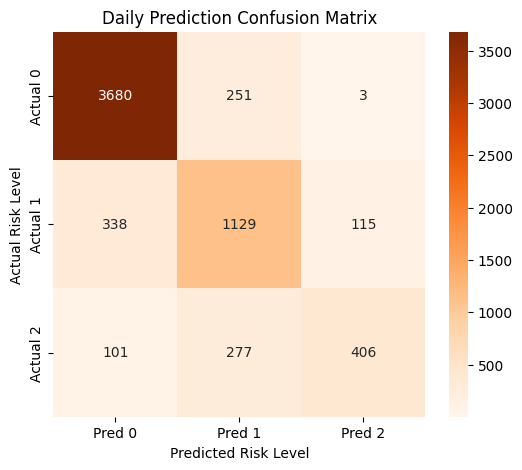

In [82]:
print("\n📊 --- 6. รายงานสรุปผลการประเมินประสิทธิภาพโมเดลบนชุดข้อสอบจริง ---")
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f"🔹 FINAL TEST DAILY MACRO ROC-AUC: {macro_auc:.4f}")
print("--------------------------------------------------")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Pre-diabetes (1)', 'Diabetes (2)']))

# พล็อต Confusion Matrix รายวัน
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])
plt.title('Daily Prediction Confusion Matrix')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.show()

# **Model Exploration**

In [83]:
# สร้าง TreeExplainer และคำนวณค่า SHAP

print("🐝 กำลังคำนวณค่า SHAP Values (อาจใช้เวลาสักครู่ตามขนาดข้อมูล)...")
# ใช้ TreeExplainer ซึ่งออกแบบมาให้คำนวณได้เร็วและแม่นยำเป็นพิเศษกับ XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

# หมายเหตุ: ใน SHAP เวอร์ชันใหม่ สำหรับโมเดลหลายคลาส
# มิติข้อมูลจะเป็น [จำนวนแถว, จำนวนฟีเจอร์, จำนวนคลาส]
# คลาส 0 = Normal, คลาส 1 = Pre-diabetes, คลาส 2 = Diabetes

🐝 กำลังคำนวณค่า SHAP Values (อาจใช้เวลาสักครู่ตามขนาดข้อมูล)...



📊 1. กำลังพล็อตคะแนนความสำคัญของฟีเจอร์นาฬิกาต่อการพยากรณ์โรคเบาหวาน (Class 2)...


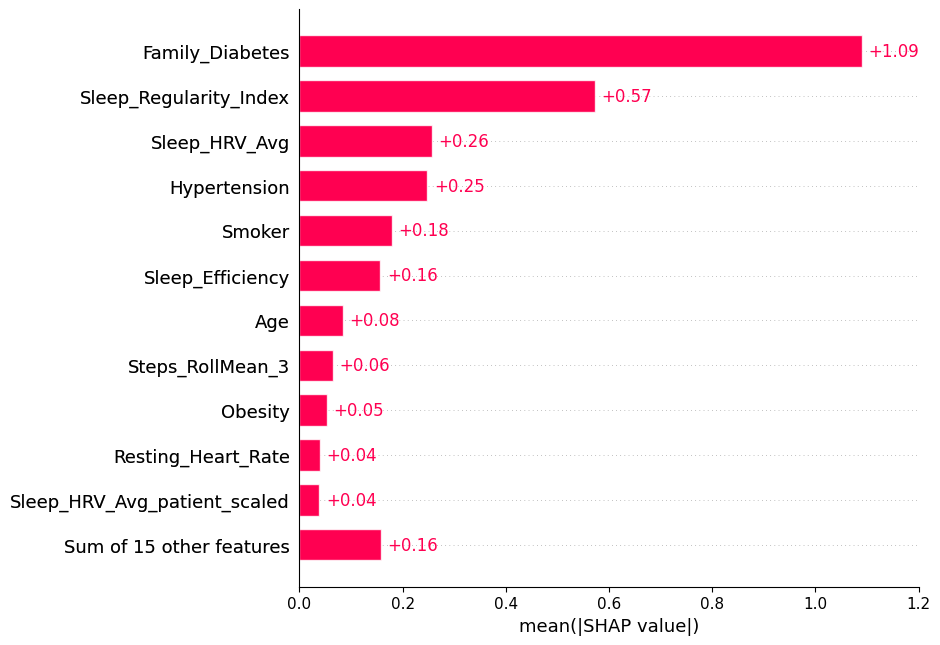

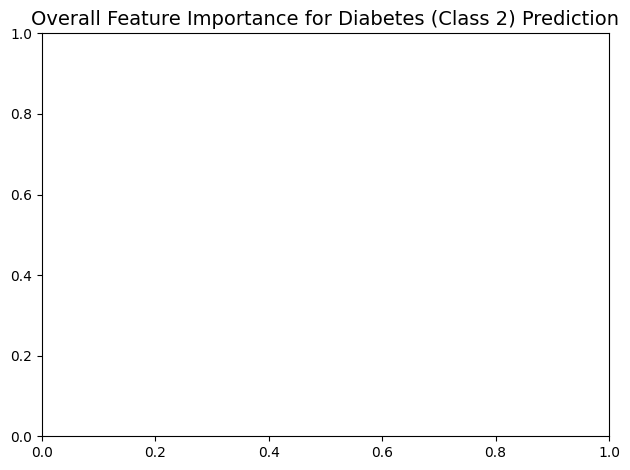

In [84]:
# PLOT 1: Global Feature Importance (Bar Plot)
print("\n📊 1. กำลังพล็อตคะแนนความสำคัญของฟีเจอร์นาฬิกาต่อการพยากรณ์โรคเบาหวาน (Class 2)...")
plt.figure(figsize=(10, 6))
# ดึงข้อมูลเฉพาะสไลซ์ของ Class 2 [:, :, 2] ออกมาพล็อต
shap.plots.bar(shap_values[:, :, 2], max_display=12)
plt.title("Overall Feature Importance for Diabetes (Class 2) Prediction", fontsize=14)
plt.tight_layout()
plt.show()


🐝 2. กำลังพล็อตทิศทางผลกระทบของข้อมูลสรีรวิทยา (Beeswarm Plot - Class 2)...


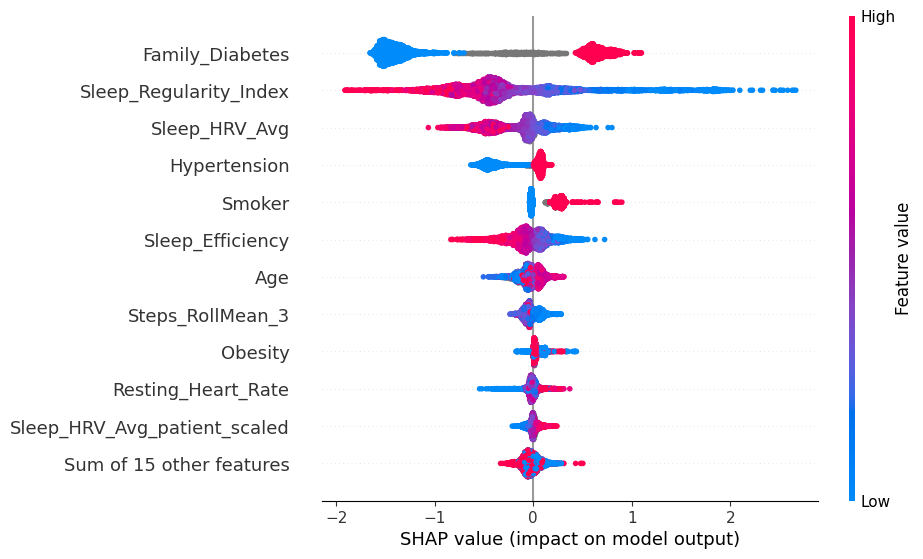

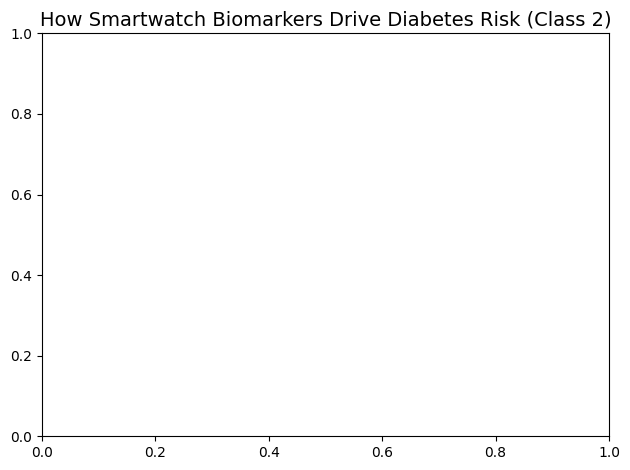

In [85]:
# PLOT 2: Feature Impact Direction (Beeswarm Plot)
print("\n🐝 2. กำลังพล็อตทิศทางผลกระทบของข้อมูลสรีรวิทยา (Beeswarm Plot - Class 2)...")
plt.figure(figsize=(10, 6))
# กราฟนี้จะบอกว่าค่าเซนเซอร์ สูง หรือ ต่ำ ที่ส่งผลให้ความเสี่ยงเบาหวานพุ่งกระฉูด
shap.plots.beeswarm(shap_values[:, :, 2], max_display=12)
plt.title("How Smartwatch Biomarkers Drive Diabetes Risk (Class 2)", fontsize=14)
plt.tight_layout()
plt.show()

# **Export Model**

In [86]:
final_model.save_model("smartwatch_diabetes_model_v2.json")